# AGU-Net & AGResU-Net — BraTS 2019 Brain Tumor Segmentation

## Paper
*Attention Gate ResU-Net for Automatic MRI Brain Tumor Segmentation*
## Dataset
**BraTS 2019**: We uploaded a subset as two files HGG and LGG to the Kaggle dataset.

* original dataset: **335 patients** (259 HGG + 76 LGG)
* Subset used: **160 patients** (128 HGG + 32 LGG), preserving the 80/20 ratio

## Models Implemented
* **U-Net** (baseline)
* **ResU-Net** (baseline)
* **AGU-Net**: U-Net + Attention Gates
* **AGResU-Net** (main model): ResU-Net + Attention Gates


**Trained on: Kaggle GPU (P100)**

In [ ]:
"""!pip install nibabel -q"""

## Uploading data

In [12]:
import os, shutil
import numpy as np
import tensorflow as tf


HGG_DIR  = '/kaggle/input/datasets/nicole27/brats2019/HGG' #the path for the file on kaggle
LGG_DIR  = '/kaggle/input/datasets/nicole27/brats2019/LGG'

WORK_DIR = '/kaggle/working'
CKPT_DIR = os.path.join(WORK_DIR, 'checkpoints') #to save the best model
LOG_DIR  = os.path.join(WORK_DIR, 'logs') #to save proccesses
PLOT_DIR = os.path.join(WORK_DIR, 'plots') #to save plots

for d in [CKPT_DIR, LOG_DIR, PLOT_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'HGG patients : {len(os.listdir(HGG_DIR))}')
print(f'LGG patients : {len(os.listdir(LGG_DIR))}')
print(f'GPU available: {tf.config.list_physical_devices("GPU")}') #checking if GPU on kaggle is working

HGG patients : 128
LGG patients : 32
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Splitting the data (6 : 2 : 2)

In [13]:
np.random.seed(42)

hgg_patients = sorted([
    os.path.join(HGG_DIR, p)
    for p in os.listdir(HGG_DIR)
    if os.path.isdir(os.path.join(HGG_DIR, p))
])
lgg_patients = sorted([
    os.path.join(LGG_DIR, p)
    for p in os.listdir(LGG_DIR)
    if os.path.isdir(os.path.join(LGG_DIR, p))
])

print(f'Available — HGG: {len(hgg_patients)}  LGG: {len(lgg_patients)}')

np.random.shuffle(hgg_patients)
np.random.shuffle(lgg_patients)

N_HGG = len(hgg_patients)
N_LGG = len(lgg_patients)
all_patients = hgg_patients[:N_HGG] + lgg_patients[:N_LGG]
np.random.shuffle(all_patients) #since they're ordered

n_train = int(len(all_patients)* 0.6)
n_val = int(len(all_patients)* 0.2)

train_dirs = all_patients[:n_train]
val_dirs = all_patients[n_train : n_train + n_val]
test_dirs = all_patients[n_train + n_val :]

print(f'Subset : {len(all_patients)} patients ({N_HGG} HGG + {N_LGG} LGG)')
print(f'Train  : {len(train_dirs)}')
print(f'Val    : {len(val_dirs)}')
print(f'Test   : {len(test_dirs)}')

Available — HGG: 128  LGG: 32
Subset : 160 patients (128 HGG + 32 LGG)
Train  : 96
Val    : 32
Test   : 32


## Preprocessing

In [14]:
import nibabel as nib

PATCH = 128
CROP_Y0 = (240 - PATCH) // 2
CROP_X0 = (240 - PATCH) // 2

def preload_data(patient_dirs, augment=False):
    #Loading all tumour-containing 128×128 slices into RAM because the session crashes with us otherwise.
    all_X, all_y = [], []
    for i, pdir in enumerate(patient_dirs):
        pid = os.path.basename(pdir)
        print(f'  Loading {i+1}/{len(patient_dirs)}: {pid}', end='\r')

        #Loading the 4 MRI modalities
        mods = []
        for mod in ['flair', 't1', 't1ce', 't2']:
            path = os.path.join(pdir, f'{pid}_{mod}.nii')
            mods.append(nib.load(path).get_fdata(dtype=np.float32))
        volume = np.stack(mods, axis=-1)   # dimensions: (240, 240, 155, 4)

        #Loading segmentation and we remapped label 4 → 3
        #since the dataset uses (0,1,2,4)
        seg_path = os.path.join(pdir, f'{pid}_seg.nii')
        seg = nib.load(seg_path).get_fdata().astype(np.uint8)
        seg[seg == 4] = 3 #classes: 0 healthy, 1 necrosis, 2 edema, 3 enhancing

        #Remove top/bottom 1% intensity per modality
        for c in range(4):
            lo = np.percentile(volume[..., c], 1)
            hi = np.percentile(volume[..., c], 99)
            volume[..., c] = np.clip(volume[..., c], lo, hi)

        #Iterate slices and only keep tumour slices (3d -> 2d)
        for z in range(volume.shape[2]):
            if seg[:, :, z].max() == 0:
                continue

            slc  = volume[:, :, z, :].copy()#dimensions: (240, 240, 4)
            mask = seg[:, :, z]#(240, 240)

            #Z-score normalisation per modality per slice
            for c in range(4):
                mu    = slc[..., c].mean()
                sigma = slc[..., c].std() + 1e-8
                slc[..., c] = (slc[..., c] - mu) / sigma

            #Gaussian noise augmentation (training data only)
            if augment:
                slc = slc + np.random.normal(0, 0.01, slc.shape).astype(np.float32)

            #Centre-crop to 128×128
            slc  = slc [CROP_Y0:CROP_Y0+PATCH, CROP_X0:CROP_X0+PATCH, :] # (128,128,4)
            mask = mask[CROP_Y0:CROP_Y0+PATCH, CROP_X0:CROP_X0+PATCH] # (128,128)

            all_X.append(slc)
            all_y.append(mask)

    print()
    X = np.stack(all_X, axis=0).astype(np.float32) # (N,128,128,4)
    y = np.stack(all_y, axis=0).astype(np.uint8) # (N,128,128)
    return X, y

print('Loading training data ...')
X_train, y_train = preload_data(train_dirs, augment=True)
print(f'Train   : X={X_train.shape}  y={y_train.shape}')

print('Loading validation data ...')
X_val, y_val = preload_data(val_dirs, augment=False)
print(f'Val     : X={X_val.shape}  y={y_val.shape}')

print('Loading test data ...')
X_test, y_test = preload_data(test_dirs, augment=False)
print(f'Test    : X={X_test.shape}  y={y_test.shape}')

Loading training data ...
  Loading 96/96: BraTS19_TCIA03_265_1
Train   : X=(6382, 128, 128, 4)  y=(6382, 128, 128)
Loading validation data ...
  Loading 32/32: BraTS19_TCIA02_135_1
Val     : X=(2282, 128, 128, 4)  y=(2282, 128, 128)
Loading test data ...
  Loading 32/32: BraTS19_TCIA13_633_1
Test    : X=(2038, 128, 128, 4)  y=(2038, 128, 128)


In [15]:
#one-hot encoding the labels (0 healty, 1 necrosis, 2 edema, 3 enhancing)
from tensorflow.keras.utils import to_categorical

NUM_CLASSES = 4
y_train_oh = to_categorical(y_train, NUM_CLASSES).astype(np.float32)
y_val_oh   = to_categorical(y_val,   NUM_CLASSES).astype(np.float32)
y_test_oh  = to_categorical(y_test,  NUM_CLASSES).astype(np.float32)

print(f'y_train one-hot : {y_train_oh.shape}')
print(f'y_val   one-hot : {y_val_oh.shape}')
print(f'y_test  one-hot : {y_test_oh.shape}')

y_train one-hot : (6382, 128, 128, 4)
y_val   one-hot : (2282, 128, 128, 4)
y_test  one-hot : (2038, 128, 128, 4)


##Creating the Models

In [16]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import tensorflow.keras.backend as K

#creating the building blocks for all the models

def conv_bn_prelu(x, filters, kernel_size=3, strides=1):
    x = layers.BatchNormalization()(x) #1.BN
    x = layers.PReLU(shared_axes=[1, 2])(x) #2.PReLU
    x = layers.Conv2D(filters, kernel_size, strides=strides, #3.Convolution
                      padding='same',
                      kernel_initializer='glorot_uniform',
                      use_bias=False)(x)
    return x


def plain_block(x, filters): #2 conv units used in U-Net
    x = conv_bn_prelu(x, filters)
    x = conv_bn_prelu(x, filters)
    return x


def residual_block(x, filters): #2 conv units + identity shortcut for ResU-Net / AGResU-Net
    shortcut = layers.Conv2D(filters, 1, padding='same',
                             kernel_initializer='glorot_uniform',
                             use_bias=False)(x)
    shortcut = layers.BatchNormalization()(shortcut)

    x = conv_bn_prelu(x, filters)
    x = conv_bn_prelu(x, filters)
    x = layers.Add()([x, shortcut])
    return x


def downsample_stride2(x, filters): #3×3 conv for downsampling
    x = layers.BatchNormalization()(x)
    x = layers.PReLU(shared_axes=[1, 2])(x)
    x = layers.Conv2D(filters, 3, strides=2, padding='same', kernel_initializer='glorot_uniform', use_bias=False)(x)
    return x


def attention_gate(xl, g, inter_channels):
    #1×1 channel-wise linear transforms
    Wx = layers.Conv2D(inter_channels, 1, padding='same', kernel_initializer='glorot_uniform', use_bias=True)(xl)
    Wg = layers.Conv2D(inter_channels, 1, padding='same', kernel_initializer='glorot_uniform', use_bias=True)(g)
    if K.int_shape(Wg)[1] != K.int_shape(Wx)[1]:
        Wg = layers.UpSampling2D(size=2, interpolation='bilinear')(Wg)

    #additive attention gate
    psi = layers.Add()([Wx, Wg])
    psi = layers.Activation('relu')(psi)
    psi = layers.Conv2D(1, 1, padding='same', kernel_initializer='glorot_uniform', use_bias=True)(psi)
    alpha = layers.Activation('sigmoid')(psi)

    if K.int_shape(alpha)[1] != K.int_shape(xl)[1]:
        alpha = layers.UpSampling2D(size=2, interpolation='bilinear')(alpha)

    return layers.Multiply()([xl, alpha])


print('Building blocks defined.')

Building blocks defined.


In [17]:
#building the models

def build_unet(input_shape=(128, 128, 4), num_classes=4):
    inp = layers.Input(shape=input_shape)

    #encoder (from 128×128×64 -> 64×64×128 -> 32×32×256 -> 16×16×512)
    e1 = plain_block(inp, 64)
    e1_down = downsample_stride2(e1, 128)
    e2 = plain_block(e1_down, 128)
    e2_down = downsample_stride2(e2, 256)
    e3 = plain_block(e2_down, 256)
    e3_down = downsample_stride2(e3, 512)

    #bridge (16×16×512)
    bridge = plain_block(e3_down, 512)

    #decoder (32×32×256 -> 64×64×128 -> back to 128×128×64)
    d3 = layers.UpSampling2D(size=2, interpolation='bilinear')(bridge)
    d3 = layers.Conv2D(256, 3, padding='same', kernel_initializer='glorot_uniform', use_bias=False)(d3)
    d3 = layers.Concatenate()([d3, e3])
    d3 = plain_block(d3, 256)

    d2 = layers.UpSampling2D(size=2, interpolation='bilinear')(d3)
    d2 = layers.Conv2D(128, 3, padding='same', kernel_initializer='glorot_uniform', use_bias=False)(d2)
    d2 = layers.Concatenate()([d2, e2])
    d2 = plain_block(d2, 128)

    d1 = layers.UpSampling2D(size=2, interpolation='bilinear')(d2)
    d1 = layers.Conv2D(64, 3, padding='same', kernel_initializer='glorot_uniform', use_bias=False)(d1)
    d1 = layers.Concatenate()([d1, e1])
    d1 = plain_block(d1, 64)

    out = layers.Conv2D(num_classes, 1, activation='softmax', kernel_initializer='glorot_uniform')(d1)
    return Model(inp, out, name='U-Net')


def build_resunet(input_shape=(128, 128, 4), num_classes=4): #same thing but using residual blocks in place of plain blocks
    inp = layers.Input(shape=input_shape)

    #encoder
    e1 = residual_block(inp, 64)
    e1_down = downsample_stride2(e1, 128)

    e2 = residual_block(e1_down, 128)
    e2_down = downsample_stride2(e2, 256)

    e3 = residual_block(e2_down, 256)
    e3_down = downsample_stride2(e3, 512)

    #bridge
    bridge = residual_block(e3_down, 512)

    #decoder
    d3 = layers.UpSampling2D(size=2, interpolation='bilinear')(bridge)
    d3 = layers.Conv2D(256, 3, padding='same', kernel_initializer='glorot_uniform', use_bias=False)(d3)
    d3 = layers.Concatenate()([d3, e3])
    d3 = residual_block(d3, 256)

    d2 = layers.UpSampling2D(size=2, interpolation='bilinear')(d3)
    d2 = layers.Conv2D(128, 3, padding='same', kernel_initializer='glorot_uniform', use_bias=False)(d2)
    d2 = layers.Concatenate()([d2, e2])
    d2 = residual_block(d2, 128)

    d1 = layers.UpSampling2D(size=2, interpolation='bilinear')(d2)
    d1 = layers.Conv2D(64, 3, padding='same', kernel_initializer='glorot_uniform', use_bias=False)(d1)
    d1 = layers.Concatenate()([d1, e1])
    d1 = residual_block(d1, 64)

    out = layers.Conv2D(num_classes, 1, activation='softmax',
                        kernel_initializer='glorot_uniform')(d1)
    return Model(inp, out, name='ResU-Net')


def build_agunet(input_shape=(128, 128, 4), num_classes=4): #U-Net + attention gates
    inp = layers.Input(shape=input_shape)

    #encoder
    e1 = plain_block(inp, 64)
    e1_down = downsample_stride2(e1, 128)

    e2 = plain_block(e1_down, 128)
    e2_down = downsample_stride2(e2, 256)

    e3 = plain_block(e2_down, 256)
    e3_down = downsample_stride2(e3, 512)

    #bridge
    bridge = plain_block(e3_down, 512)

    #decoder with attention gates added on skip connections
    d3_up = layers.UpSampling2D(size=2, interpolation='bilinear')(bridge)
    d3_up = layers.Conv2D(256, 3, padding='same', kernel_initializer='glorot_uniform', use_bias=False)(d3_up)
    e3_ag = attention_gate(xl=e3, g=bridge, inter_channels=256) #AG
    d3 = layers.Concatenate()([d3_up, e3_ag])
    d3 = plain_block(d3, 256)

    d2_up = layers.UpSampling2D(size=2, interpolation='bilinear')(d3)
    d2_up = layers.Conv2D(128, 3, padding='same', kernel_initializer='glorot_uniform', use_bias=False)(d2_up)
    e2_ag = attention_gate(xl=e2, g=d3, inter_channels=128)
    d2 = layers.Concatenate()([d2_up, e2_ag])
    d2 = plain_block(d2, 128)

    d1_up = layers.UpSampling2D(size=2, interpolation='bilinear')(d2)
    d1_up = layers.Conv2D(64, 3, padding='same', kernel_initializer='glorot_uniform', use_bias=False)(d1_up)
    e1_ag = attention_gate(xl=e1, g=d2, inter_channels=64)
    d1 = layers.Concatenate()([d1_up, e1_ag])
    d1 = plain_block(d1, 64)

    out = layers.Conv2D(num_classes, 1, activation='softmax',
                        kernel_initializer='glorot_uniform')(d1)
    return Model(inp, out, name='AGU-Net')


def build_agresunet(input_shape=(128, 128, 4), num_classes=4): #residual blocks + attention gates
    inp = layers.Input(shape=input_shape)

    #envoder
    e1 = residual_block(inp, 64)
    e1_down = downsample_stride2(e1, 128)

    e2 = residual_block(e1_down, 128)
    e2_down = downsample_stride2(e2, 256)

    e3 = residual_block(e2_down, 256)
    e3_down = downsample_stride2(e3, 512)

    #bridge
    bridge = residual_block(e3_down, 512)

    #decoder
    d3_up = layers.UpSampling2D(size=2, interpolation='bilinear')(bridge)
    d3_up = layers.Conv2D(256, 3, padding='same', kernel_initializer='glorot_uniform', use_bias=False)(d3_up)
    e3_ag = attention_gate(xl=e3, g=bridge, inter_channels=256)
    d3 = layers.Concatenate()([d3_up, e3_ag])
    d3 = residual_block(d3, 256)

    d2_up = layers.UpSampling2D(size=2, interpolation='bilinear')(d3)
    d2_up = layers.Conv2D(128, 3, padding='same', kernel_initializer='glorot_uniform', use_bias=False)(d2_up)
    e2_ag = attention_gate(xl=e2, g=d3, inter_channels=128)
    d2 = layers.Concatenate()([d2_up, e2_ag])
    d2 = residual_block(d2, 128)

    d1_up = layers.UpSampling2D(size=2, interpolation='bilinear')(d2)
    d1_up = layers.Conv2D(64, 3, padding='same', kernel_initializer='glorot_uniform', use_bias=False)(d1_up)
    e1_ag = attention_gate(xl=e1, g=d2, inter_channels=64)
    d1 = layers.Concatenate()([d1_up, e1_ag])
    d1 = residual_block(d1, 64)

    out = layers.Conv2D(num_classes, 1, activation='softmax',
                        kernel_initializer='glorot_uniform')(d1)
    return Model(inp, out, name='AGResU-Net')

## Loss Function

In [18]:
def generalised_dice_loss(y_true, y_pred, eps=1e-8):
    #flatten spatial dimensions
    y_true_f = tf.reshape(y_true, [-1, NUM_CLASSES])
    y_pred_f = tf.reshape(y_pred, [-1, NUM_CLASSES])

    #per-class weight: 1/(sum of ground-truth voxels)²
    class_counts = tf.reduce_sum(y_true_f, axis=0)
    weights = 1.0 / (tf.square(class_counts) + eps)

    numerator   = tf.reduce_sum(weights * tf.reduce_sum(y_true_f * y_pred_f, axis=0))
    denominator = tf.reduce_sum(weights * tf.reduce_sum(y_true_f + y_pred_f, axis=0))
    return 1.0 - 2.0 * numerator / (denominator + eps)


def weighted_cross_entropy(y_true, y_pred, eps=1e-8): #weight per label = 1 / (Σ g_ik)²
    y_true_f = tf.reshape(y_true, [-1, NUM_CLASSES])
    y_pred_f = tf.reshape(y_pred, [-1, NUM_CLASSES])

    class_counts = tf.reduce_sum(y_true_f, axis=0)
    weights = 1.0 / (tf.square(class_counts) + eps)

    log_pred = tf.math.log(tf.clip_by_value(y_pred_f, eps, 1.0))
    wce = -tf.reduce_sum(weights * tf.reduce_sum(y_true_f * log_pred, axis=0))
    return wce

LAMBDA = 1.0 #hyper-parameter λ is 1 in the paper

def combined_loss(y_true, y_pred):
    return generalised_dice_loss(y_true, y_pred) + LAMBDA * weighted_cross_entropy(y_true, y_pred)

def dsc_metric(y_true, y_pred, eps=1e-8):
    y_true_f = tf.reshape(y_true, [-1, NUM_CLASSES])
    y_pred_f = tf.reshape(tf.one_hot(tf.argmax(y_pred, axis=-1), NUM_CLASSES), [-1, NUM_CLASSES])
    y_pred_f = tf.cast(y_pred_f, tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=0)
    dsc = (2.0 * intersection + eps) / (
        tf.reduce_sum(y_true_f, axis=0) + tf.reduce_sum(y_pred_f, axis=0) + eps
    )
    return tf.reduce_mean(dsc[1:])#excluding background class 0 (healthy)

print('Loss and metric functions defined.')

Loss and metric functions defined.


## Training
* **Optimizer**: SGD, lr = 0.086 (we used 0.01 since our model kept overfitting (0.086 was too harsh) because of the small subset we used, momentum = 0.97
* **Epochs**: 40
* **Batch size**: patch-slice (16)

In [19]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

EPOCHS     = 40
BATCH_SIZE = 16

def make_optimizer():
    return tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.97) #learning rate is reduced


def train_model(model, model_name):
    print(f'\n{'='*60}')
    print(f'  Training {model_name}')
    print(f'{'='*60}')

    model.compile(
        optimizer=make_optimizer(),
        loss=combined_loss,
        metrics=[dsc_metric]
    )

    ckpt_path = os.path.join(CKPT_DIR, f'{model_name}_best.keras') #save best model

    callbacks = [
        ModelCheckpoint( #saving the best model weights based on highest val DSC
            ckpt_path,
            monitor='val_dsc_metric',
            mode='max',
            save_best_only=True,
            verbose=1
        ),
        ReduceLROnPlateau( #halves the learning rate if val loss stops improving for 5 epochs
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1
        ),
        EarlyStopping( #stops training early and restores best weights to prevent overfitting
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
    ]

    history = model.fit(
        X_train, y_train_oh,
        validation_data=(X_val, y_val_oh),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )

    print(f'  Best val DSC saved to {ckpt_path}')
    return history


#building and training all models
model_unet = build_unet()
model_resunet = build_resunet()
model_agunet = build_agunet()
model_agresunet = build_agresunet()

history_unet = train_model(model_unet,'U-Net')
history_resunet = train_model(model_resunet,'ResU-Net')
history_agunet = train_model(model_agunet,'AGU-Net')
history_agresunet = train_model(model_agresunet,'AGResU-Net')

I0000 00:00:1778337737.163870      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0



  Training U-Net
Epoch 1/40


I0000 00:00:1778337753.822045     185 service.cc:152] XLA service 0x7bf71c02eee0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778337753.822088     185 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778337754.894272     185 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/399 ━━━━━━━━━━━━━━━━━━━━ 2:33:45 23s/step - dsc_metric: 0.0465 - loss: 0.9655

I0000 00:00:1778337770.754346     185 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


398/399 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - dsc_metric: 0.4715 - loss: 0.5579

2026-05-09 14:43:54.997564: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 14:43:55.232748: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


399/399 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - dsc_metric: 0.4717 - loss: 0.5576

2026-05-09 14:44:20.581691: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 14:44:20.815742: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_dsc_metric improved from -inf to 0.29075, saving model to /kaggle/working/checkpoints/U-Net_best.keras
399/399 ━━━━━━━━━━━━━━━━━━━━ 115s 232ms/step - dsc_metric: 0.4720 - loss: 0.5573 - val_dsc_metric: 0.2907 - val_loss: 1.2028 - learning_rate: 0.0100
Epoch 2/40
399/399 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - dsc_metric: 0.6532 - loss: 0.3623
Epoch 2: val_dsc_metric did not improve from 0.29075
399/399 ━━━━━━━━━━━━━━━━━━━━ 68s 170ms/step - dsc_metric: 0.6532 - loss: 0.3623 - val_dsc_metric: 0.2247 - val_loss: 1.2422 - learning_rate: 0.0100
Epoch 3/40
399/399 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - dsc_metric: 0.6919 - loss: 0.3154
Epoch 3: val_dsc_metric improved from 0.29075 to 0.47699, saving model to /kaggle/working/checkpoints/U-Net_best.keras
399/399 ━━━━━━━━━━━━━━━━━━━━ 68s 171ms/step - dsc_metric: 0.6919 - loss: 0.3154 - val_dsc_metric: 0.4770 - val_loss: 0.9856 - learning_rate: 0.0100
Epoch 4/40
399/399 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - dsc_metric: 0.7273 - loss: 0.2

In [20]:
from tensorflow.keras.models import load_model
import os

#loading best checkpoints
model_unet = load_model(os.path.join(CKPT_DIR, 'U-Net_best.keras'),
                             custom_objects={'combined_loss': combined_loss, 'dsc_metric': dsc_metric})
model_resunet = load_model(os.path.join(CKPT_DIR, 'ResU-Net_best.keras'),
                             custom_objects={'combined_loss': combined_loss, 'dsc_metric': dsc_metric})
model_agunet = load_model(os.path.join(CKPT_DIR, 'AGU-Net_best.keras'),
                             custom_objects={'combined_loss': combined_loss, 'dsc_metric': dsc_metric})
model_agresunet = load_model(os.path.join(CKPT_DIR, 'AGResU-Net_best.keras'),
                             custom_objects={'combined_loss': combined_loss, 'dsc_metric': dsc_metric})

models_dict = {
    'U-Net'     : model_unet,
    'ResU-Net'  : model_resunet,
    'AGU-Net'   : model_agunet,
    'AGResU-Net': model_agresunet,
}
print('Best checkpoints loaded.')

Best checkpoints loaded.


##Evaluation

In [21]:
#Dice similarity coefficient(DSC) and Hausdorff95
from scipy.ndimage import distance_transform_edt

def compute_dsc(pred_mask, true_mask):
    intersection = np.logical_and(pred_mask, true_mask).sum()
    total = pred_mask.sum() + true_mask.sum()
    if total == 0:
        return 1.0 #if both empty thats a perfect match
    return 2.0 * intersection / total


def compute_hd95(pred_mask, true_mask):
    if pred_mask.sum() == 0 or true_mask.sum() == 0:
        return np.nan
    dist_pred = distance_transform_edt(~pred_mask)
    dist_true = distance_transform_edt(~true_mask)
    surf_pred = dist_true[pred_mask > 0]
    surf_true = dist_pred[true_mask > 0]
    all_dists  = np.concatenate([surf_pred, surf_true])
    return np.percentile(all_dists, 95)


def evaluate_model(model, X, y_true_labels, batch_size=16): #evaluate on three tumor regions: whole, core, enhancing
    y_prob = model.predict(X, batch_size=batch_size, verbose=0)
    y_pred = np.argmax(y_prob, axis=-1)

    dsc_whole_list = []
    dsc_core_list  = []
    dsc_enh_list   = []
    hd_whole_list  = []
    hd_core_list   = []
    hd_enh_list    = []

    for i in range(len(y_pred)):
        p = y_pred[i]
        t = y_true_labels[i]

        #whole tumor:(1,2,3)
        p_whole = p > 0
        t_whole = t > 0
        dsc_whole_list.append(compute_dsc(p_whole, t_whole))
        hd_whole_list.append(compute_hd95(p_whole, t_whole))

        #core tumor:(1,3)
        p_core = np.isin(p, [1, 3])
        t_core = np.isin(t, [1, 3])
        dsc_core_list.append(compute_dsc(p_core, t_core))
        hd_core_list.append(compute_hd95(p_core, t_core))

        #enhancing tumor:3 only
        p_enh = (p == 3)
        t_enh = (t == 3)
        dsc_enh_list.append(compute_dsc(p_enh, t_enh))
        hd_enh_list.append(compute_hd95(p_enh, t_enh))

    return {
        'dsc_whole': np.nanmean(dsc_whole_list),
        'dsc_core': np.nanmean(dsc_core_list),
        'dsc_enhancing': np.nanmean(dsc_enh_list),
        'hd95_whole': np.nanmean(hd_whole_list),
        'hd95_core': np.nanmean(hd_core_list),
        'hd95_enhancing': np.nanmean(hd_enh_list),
    }

print('Evaluating on test set ...')
models_dict = {
    'U-Net': model_unet,
    'ResU-Net': model_resunet,
    'AGU-Net': model_agunet,
    'AGResU-Net': model_agresunet,
}
all_results = {}
for name, model in models_dict.items():
    print(f'  {name} ...')
    all_results[name] = evaluate_model(model, X_test, y_test)

print('Done.')

Evaluating on test set ...
  U-Net ...


2026-05-09 17:19:38.783382: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 17:19:39.016246: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  ResU-Net ...
  AGU-Net ...
  AGResU-Net ...
Done.


In [22]:
#results table
#paper table 8 baselines (BraTS 2019 validation, full dataset)
paper_results = {
    'U-Net†'     : {'dsc_whole': 0.864, 'dsc_core': 0.746, 'dsc_enhancing': 0.696,
                    'hd95_whole': None, 'hd95_core': None, 'hd95_enhancing': None},
    'ResU-Net†'  : {'dsc_whole': 0.867, 'dsc_core': 0.760, 'dsc_enhancing': 0.704,
                    'hd95_whole': None, 'hd95_core': None, 'hd95_enhancing': None},
    'AGU-Net†'   : {'dsc_whole': 0.870, 'dsc_core': 0.760, 'dsc_enhancing': 0.700,
                    'hd95_whole': None, 'hd95_core': None, 'hd95_enhancing': None},
    'AGResU-Net†': {'dsc_whole': 0.870, 'dsc_core': 0.777, 'dsc_enhancing': 0.709,
                    'hd95_whole': None, 'hd95_core': None, 'hd95_enhancing': None},
}

combined = {**paper_results, **all_results}

print(f'\n{"="*82}')
print('  RESULTS — BraTS 2019  († = paper full-dataset values; ours = 160-patient subset)')
print(f'  {"-"*78}')
print(f'  {"Model":<18} {"DSC-Whole":>10} {"DSC-Core":>10} {"DSC-Enh":>10}'
      f' {"HD95-W":>8} {"HD95-C":>8} {"HD95-E":>8}')
print(f'  {"-"*78}')
for name, r in combined.items():
    hd_w = f'{r["hd95_whole"]:8.2f}'      if r['hd95_whole']      is not None else '       —'
    hd_c = f'{r["hd95_core"]:8.2f}'       if r['hd95_core']       is not None else '       —'
    hd_e = f'{r["hd95_enhancing"]:8.2f}'  if r['hd95_enhancing']  is not None else '       —'
    print(f'  {name:<18} {r["dsc_whole"]:>10.3f} {r["dsc_core"]:>10.3f}'
          f' {r["dsc_enhancing"]:>10.3f} {hd_w} {hd_c} {hd_e}')
print(f'  {"-"*78}')
print('  † Paper values on full BraTS 2019 (335 patients) at full resolution.')
print(f'{"="*82}')


  RESULTS — BraTS 2019  († = paper full-dataset values; ours = 160-patient subset)
  ------------------------------------------------------------------------------
  Model               DSC-Whole   DSC-Core    DSC-Enh   HD95-W   HD95-C   HD95-E
  ------------------------------------------------------------------------------
  U-Net†                  0.864      0.746      0.696        —        —        —
  ResU-Net†               0.867      0.760      0.704        —        —        —
  AGU-Net†                0.870      0.760      0.700        —        —        —
  AGResU-Net†             0.870      0.777      0.709        —        —        —
  U-Net                   0.701      0.712      0.768     9.23     5.42     3.14
  ResU-Net                0.694      0.700      0.781     8.37     6.05     3.43
  AGU-Net                 0.711      0.702      0.783     9.98     6.51     3.10
  AGResU-Net              0.721      0.694      0.770    10.60     5.68     3.50
  -----------------------

##Training Curves

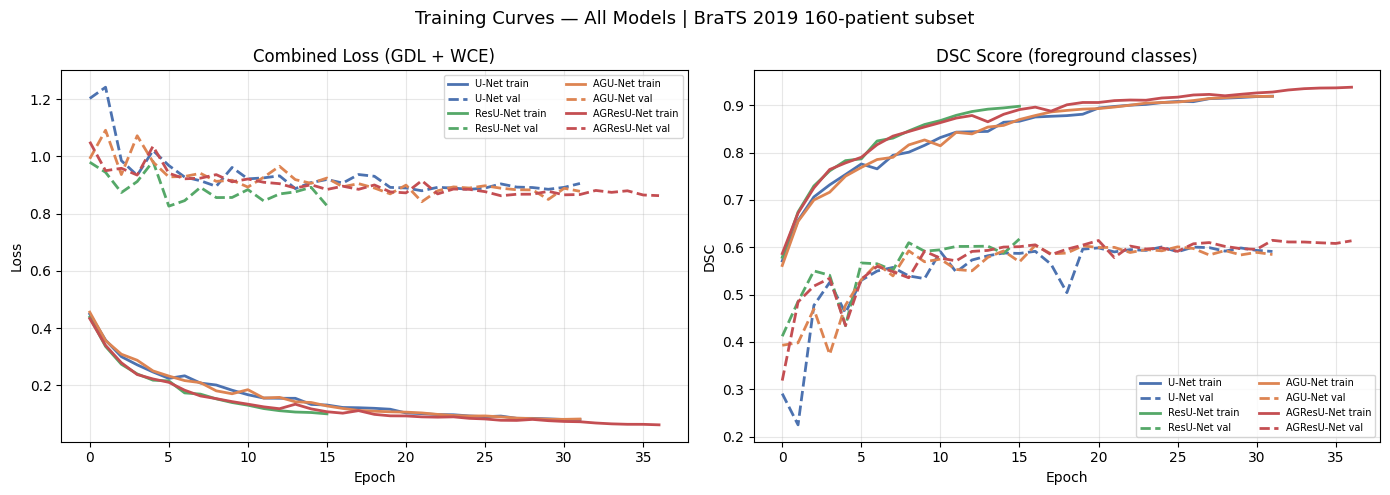

Saved to /kaggle/working/plots/training_curves.png


In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

histories = {
    'U-Net'     : history_unet,
    'ResU-Net'  : history_resunet,
    'AGU-Net'   : history_agunet,
    'AGResU-Net': history_agresunet,
}
colors = ['#4C72B0', '#55A868', '#DD8452', '#C44E52']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (name, h), color in zip(histories.items(), colors):
    axes[0].plot(h.history['loss'],     label=f'{name} train', color=color, linewidth=2)
    axes[0].plot(h.history['val_loss'], label=f'{name} val',   color=color, linewidth=2, linestyle='--')
    axes[1].plot(h.history['dsc_metric'],     label=f'{name} train', color=color, linewidth=2)
    axes[1].plot(h.history['val_dsc_metric'], label=f'{name} val',   color=color, linewidth=2, linestyle='--')

axes[0].set_title('Combined Loss (GDL + WCE)',    fontsize=12)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=7, ncol=2); axes[0].grid(alpha=0.3)

axes[1].set_title('DSC Score (foreground classes)', fontsize=12)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('DSC')
axes[1].legend(fontsize=7, ncol=2); axes[1].grid(alpha=0.3)

plt.suptitle('Training Curves — All Models | BraTS 2019 160-patient subset', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'training_curves.png'), dpi=150)
plt.show()
print(f'Saved to {PLOT_DIR}/training_curves.png')

##DSC Bar Chart

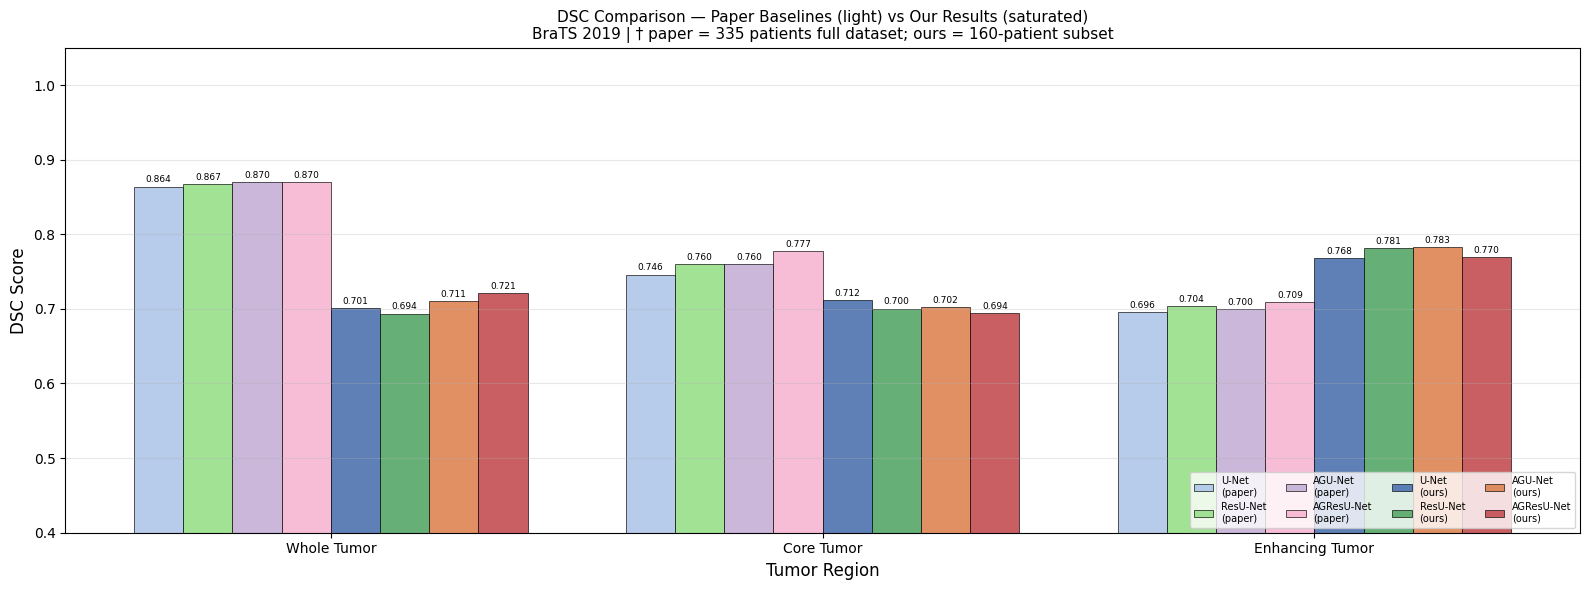

Saved to /kaggle/working/plots/dsc_comparison.png


In [24]:
#comparing paper results and our reults
regions       = ['whole', 'core', 'enhancing']
region_labels = ['Whole Tumor', 'Core Tumor', 'Enhancing Tumor']

paper_dsc = {
    'U-Net\n(paper)'     : [0.864, 0.746, 0.696],
    'ResU-Net\n(paper)'  : [0.867, 0.760, 0.704],
    'AGU-Net\n(paper)'   : [0.870, 0.760, 0.700],
    'AGResU-Net\n(paper)': [0.870, 0.777, 0.709],
}
our_dsc = {
    'U-Net\n(ours)'      : [all_results['U-Net'][f'dsc_{r}']      for r in regions],
    'ResU-Net\n(ours)'   : [all_results['ResU-Net'][f'dsc_{r}']   for r in regions],
    'AGU-Net\n(ours)'    : [all_results['AGU-Net'][f'dsc_{r}']    for r in regions],
    'AGResU-Net\n(ours)' : [all_results['AGResU-Net'][f'dsc_{r}'] for r in regions],
}

all_bars   = {**paper_dsc, **our_dsc}
bar_colors = ['#aec7e8', '#98df8a', '#c5b0d5', '#f7b6d2',
              '#4C72B0', '#55A868', '#DD8452', '#C44E52']

x     = np.arange(len(regions))
width = 0.10

fig, ax = plt.subplots(figsize=(16, 6))
for i, (name, vals) in enumerate(all_bars.items()):
    bars = ax.bar(x + i * width, vals, width, label=name,
                  color=bar_colors[i], alpha=0.9,
                  edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=6.5)

ax.set_xlabel('Tumor Region', fontsize=12)
ax.set_ylabel('DSC Score',    fontsize=12)
ax.set_title(
    'DSC Comparison — Paper Baselines (light) vs Our Results (saturated)\n'
    'BraTS 2019 | † paper = 335 patients full dataset; ours = 160-patient subset',
    fontsize=11)
ax.set_xticks(x + width * 3.5)
ax.set_xticklabels(region_labels)
ax.set_ylim(0.40, 1.05)
ax.legend(loc='lower right', fontsize=7, ncol=4)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'dsc_comparison.png'), dpi=150)
plt.show()
print(f'Saved to {PLOT_DIR}/dsc_comparison.png')

##Segmentation Overlay

2026-05-09 17:20:55.339943: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 17:20:55.572306: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


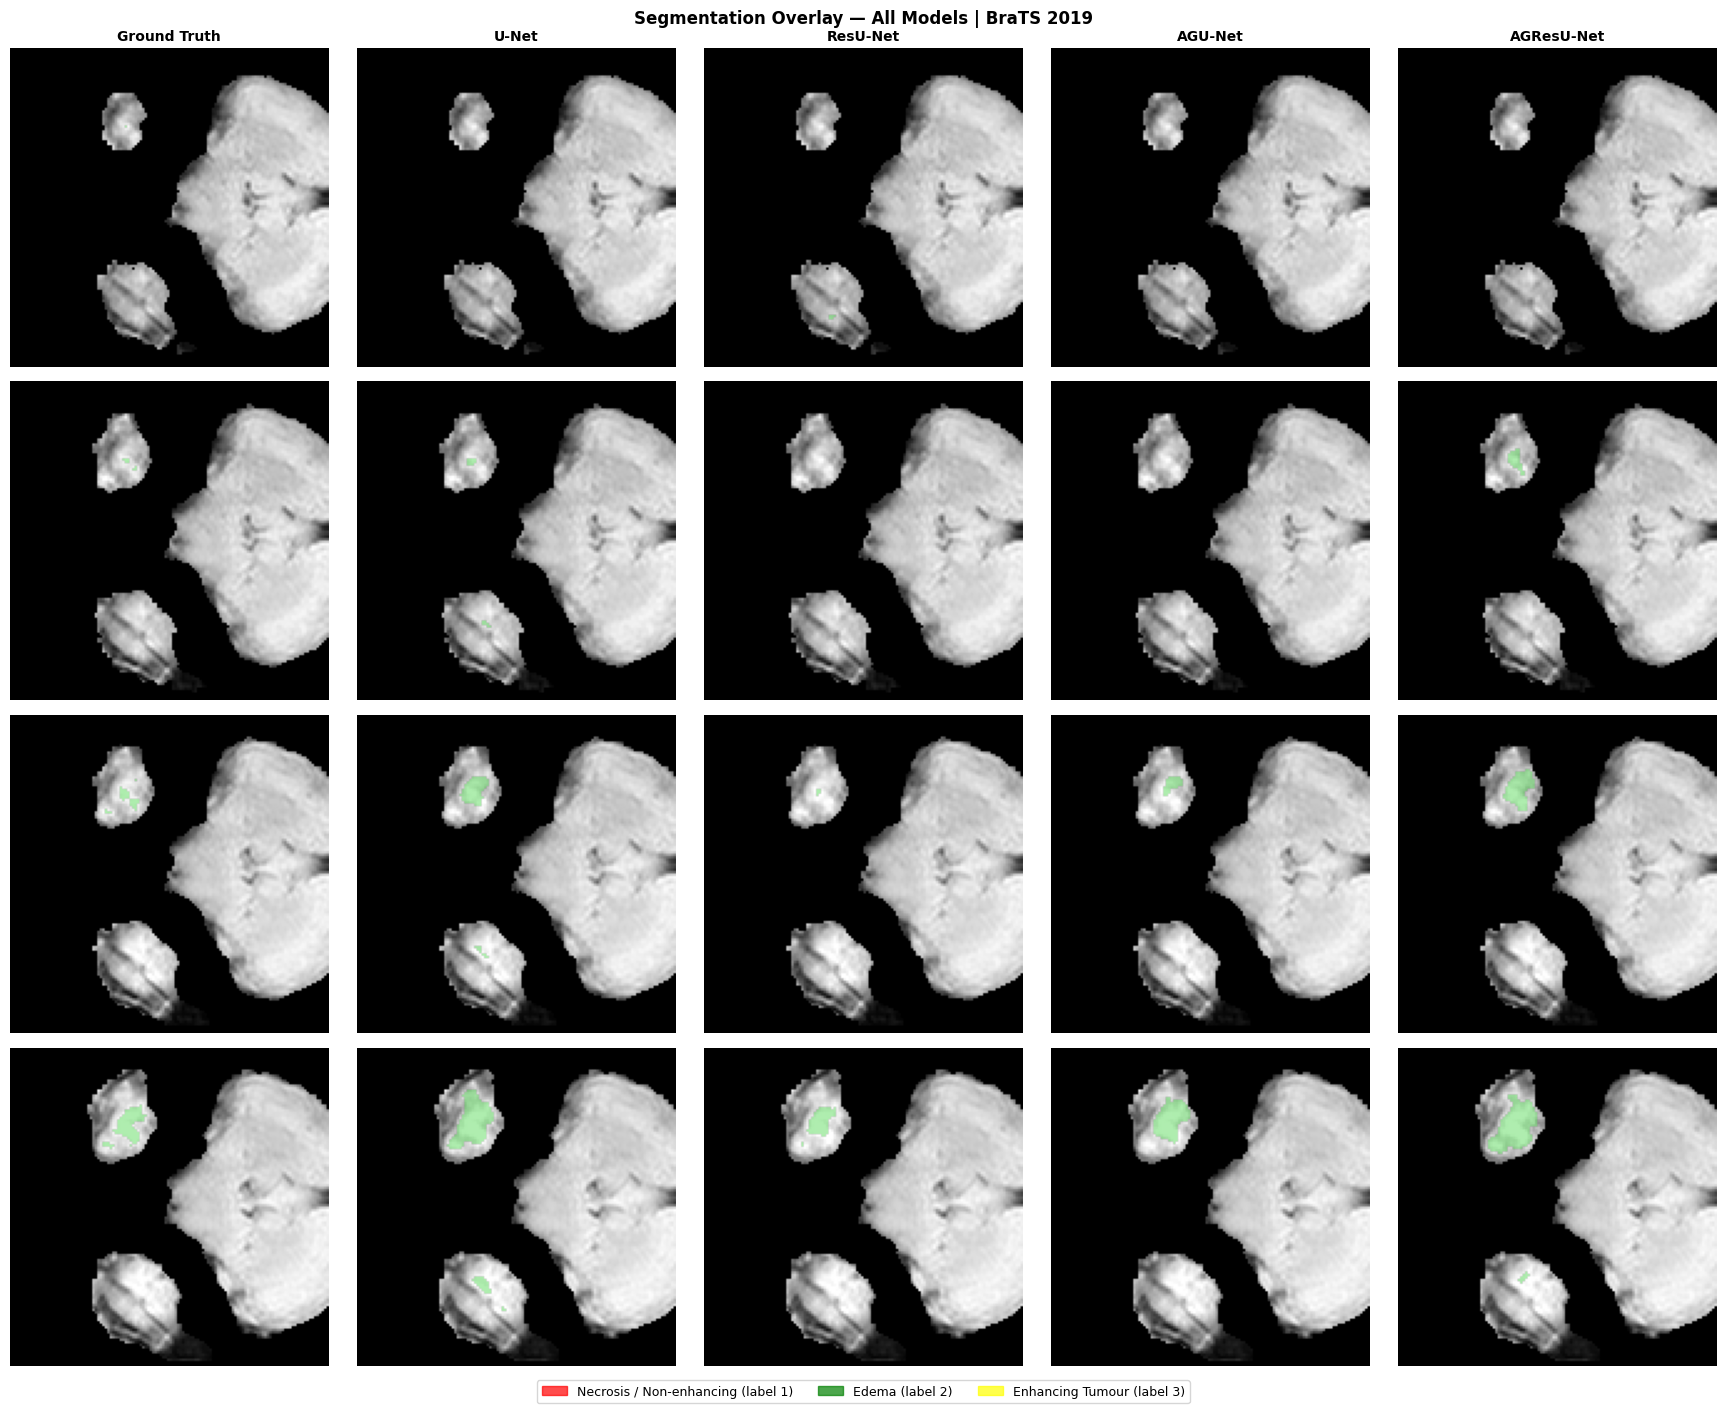

Saved to /kaggle/working/plots/segmentation_overlay.png


In [25]:
COLOR_MAP = np.array([
    [0,   0,   0,   0  ],  # class 0: background (transparent)
    [255, 0,   0,   180],  # class 1: necrosis / non-enhancing (red)
    [0,   200, 0,   180],  # class 2: edema (green)
    [255, 255, 0,   180],  # class 3: enhancing tumour (yellow)
], dtype=np.uint8)

#4 test slices that contain tumour
has_tumor  = y_test.max(axis=(1, 2)) > 0
tumor_idx  = np.where(has_tumor)[0]
sample_idx = tumor_idx[:min(4, len(tumor_idx))]

#predictions from all four models
preds = {}
for name, model in models_dict.items():
    prob = model.predict(X_test[sample_idx], batch_size=4, verbose=0)
    preds[name] = np.argmax(prob, axis=-1)

true_labels = y_test[sample_idx]
col_names   = ['Ground Truth', 'U-Net', 'ResU-Net', 'AGU-Net', 'AGResU-Net']

fig, axes = plt.subplots(
    len(sample_idx), len(col_names),
    figsize=(3.5 * len(col_names), 3.5 * len(sample_idx))
)

for row in range(len(sample_idx)):
    flair      = X_test[sample_idx[row], :, :, 0]   # Flair modality (index 0)
    flair_norm = (flair - flair.min()) / (flair.max() - flair.min() + 1e-8)
    for col, cname in enumerate(col_names):
        ax = axes[row, col]
        if cname == 'Ground Truth':
            lmap = true_labels[row]
        else:
            lmap = preds[cname][row]
        ax.imshow(flair_norm, cmap='gray')
        ax.imshow(COLOR_MAP[lmap], alpha=0.45)
        if row == 0:
            ax.set_title(cname, fontsize=10, fontweight='bold')
        ax.axis('off')

legend_handles = [
    mpatches.Patch(color='red',    alpha=0.7, label='Necrosis / Non-enhancing (label 1)'),
    mpatches.Patch(color='green',  alpha=0.7, label='Edema (label 2)'),
    mpatches.Patch(color='yellow', alpha=0.7, label='Enhancing Tumour (label 3)'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=3,
           fontsize=9, bbox_to_anchor=(0.5, -0.02))
plt.suptitle('Segmentation Overlay — All Models | BraTS 2019',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'segmentation_overlay.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {PLOT_DIR}/segmentation_overlay.png')

## Phase 4 - Enhancement

In [26]:
# Results Enhancement: TTA (Test-Time Augmentation) + Model Ensemble
# TTA: run each slice through 4 augmentations then average predictions
# Ensemble: average AGU-Net and AGResU-Net predictions together

def predict_with_tta(model, X, batch_size=16):
    # original
    p0 = model.predict(X, batch_size=batch_size, verbose=0)
    # flip left-right
    p1 = model.predict(X[:, :, ::-1, :], batch_size=batch_size, verbose=0)[:, :, ::-1, :]
    # flip up-down
    p2 = model.predict(X[:, ::-1, :, :], batch_size=batch_size, verbose=0)[:, ::-1, :, :]
    # flip both
    p3 = model.predict(X[:, ::-1, ::-1, :], batch_size=batch_size, verbose=0)[:, ::-1, ::-1, :]
    # average all 4
    return (p0 + p1 + p2 + p3) / 4.0


def evaluate_from_probs(y_prob, y_true_labels):
    # Evaluate DSC and HD95 from probability maps directly.
    y_pred = np.argmax(y_prob, axis=-1)

    dsc_whole_list, dsc_core_list, dsc_enh_list = [], [], []
    hd_whole_list,  hd_core_list,  hd_enh_list  = [], [], []

    for i in range(len(y_pred)):
        p = y_pred[i]
        t = y_true_labels[i]

        p_whole = p > 0;          t_whole = t > 0
        p_core  = np.isin(p, [1,3]); t_core  = np.isin(t, [1,3])
        p_enh   = (p == 3);       t_enh   = (t == 3)

        dsc_whole_list.append(compute_dsc(p_whole, t_whole))
        dsc_core_list.append(compute_dsc(p_core,  t_core))
        dsc_enh_list.append(compute_dsc(p_enh,   t_enh))
        hd_whole_list.append(compute_hd95(p_whole, t_whole))
        hd_core_list.append(compute_hd95(p_core,  t_core))
        hd_enh_list.append(compute_hd95(p_enh,   t_enh))

    return {
        'dsc_whole'    : np.nanmean(dsc_whole_list),
        'dsc_core'     : np.nanmean(dsc_core_list),
        'dsc_enhancing': np.nanmean(dsc_enh_list),
        'hd95_whole'   : np.nanmean(hd_whole_list),
        'hd95_core'    : np.nanmean(hd_core_list),
        'hd95_enhancing': np.nanmean(hd_enh_list),
    }


print('Running TTA for AGU-Net...')
probs_agunet_tta    = predict_with_tta(model_agunet,    X_test)

print('Running TTA for AGResU-Net...')
probs_agresunet_tta = predict_with_tta(model_agresunet, X_test)

# Ensemble = average of the two TTA probability maps
probs_ensemble = (probs_agunet_tta + probs_agresunet_tta) / 2.0

# Evaluate all three
all_results['AGU-Net + TTA']    = evaluate_from_probs(probs_agunet_tta,    y_test)
all_results['AGResU-Net + TTA'] = evaluate_from_probs(probs_agresunet_tta, y_test)
all_results['Ensemble (TTA)']   = evaluate_from_probs(probs_ensemble,      y_test)

print('Done.')

Running TTA for AGU-Net...
Running TTA for AGResU-Net...
Done.


In [27]:
# Updated results table including TTA and Ensemble
print(f'\n{"="*82}')
print('  RESULTS — BraTS 2019  († = paper full-dataset; ours = 160-patient subset)')
print(f'  {"-"*78}')
print(f'  {"Model":<22} {"DSC-Whole":>10} {"DSC-Core":>10} {"DSC-Enh":>10}'
      f' {"HD95-W":>8} {"HD95-C":>8} {"HD95-E":>8}')
print(f'  {"-"*78}')

# Paper baselines first
for name, r in paper_results.items():
    hd_w = f'{r["hd95_whole"]:8.2f}'       if r['hd95_whole']       is not None else '       —'
    hd_c = f'{r["hd95_core"]:8.2f}'        if r['hd95_core']        is not None else '       —'
    hd_e = f'{r["hd95_enhancing"]:8.2f}'   if r['hd95_enhancing']   is not None else '       —'
    print(f'  {name:<22} {r["dsc_whole"]:>10.3f} {r["dsc_core"]:>10.3f}'
          f' {r["dsc_enhancing"]:>10.3f} {hd_w} {hd_c} {hd_e}')

print(f'  {"-"*78}')

# Our results — all models including TTA and ensemble
for name in ['U-Net', 'ResU-Net', 'AGU-Net', 'AGResU-Net',
             'AGU-Net + TTA', 'AGResU-Net + TTA', 'Ensemble (TTA)']:
    r    = all_results[name]
    hd_w = f'{r["hd95_whole"]:8.2f}'
    hd_c = f'{r["hd95_core"]:8.2f}'
    hd_e = f'{r["hd95_enhancing"]:8.2f}'
    star = ' ★' if name == 'Ensemble (TTA)' else ''
    print(f'  {name+star:<22} {r["dsc_whole"]:>10.3f} {r["dsc_core"]:>10.3f}'
          f' {r["dsc_enhancing"]:>10.3f} {hd_w} {hd_c} {hd_e}')

print(f'  {"-"*78}')
print('  ★ Best result  |  † Paper values on full BraTS 2019 (335 patients).')
print(f'{"="*82}')


  RESULTS — BraTS 2019  († = paper full-dataset; ours = 160-patient subset)
  ------------------------------------------------------------------------------
  Model                   DSC-Whole   DSC-Core    DSC-Enh   HD95-W   HD95-C   HD95-E
  ------------------------------------------------------------------------------
  U-Net†                      0.864      0.746      0.696        —        —        —
  ResU-Net†                   0.867      0.760      0.704        —        —        —
  AGU-Net†                    0.870      0.760      0.700        —        —        —
  AGResU-Net†                 0.870      0.777      0.709        —        —        —
  ------------------------------------------------------------------------------
  U-Net                       0.701      0.712      0.768     9.23     5.42     3.14
  ResU-Net                    0.694      0.700      0.781     8.37     6.05     3.43
  AGU-Net                     0.711      0.702      0.783     9.98     6.51     3.10
